In [1]:
from ast import literal_eval
from collections import OrderedDict
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
import panel as pn
import plotly.express as px
import seaborn as sns
import torch
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial import procrustes
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.manifold import TSNE, LocallyLinearEmbedding
from sklearn.random_projection import GaussianRandomProjection
from torch import nn
from torch.utils.data import Subset

from nnscaling import aesthetics
from nnscaling.data import (
    DatasetConfig,
    create_data_loader,
    get_dataset_class,
)
from nnscaling.models import MLP, ScaledModel

%load_ext autoreload
%autoreload 2

In [2]:
target_class = 0

In [3]:
# Dataset config
dataset_config = DatasetConfig(
    dataset_name="LotusRootDataset",
    num_samples=5_000,
    split="train",
    seed=42,
)
DatasetClass = get_dataset_class(name=dataset_config.dataset_name)
train_dataset = DatasetClass(config=dataset_config)
in_features = train_dataset.features.shape[-1]

In [4]:
file_path = "/home/nsa325/work/nnscaling/model_saves/lotusroot_model.safetensors"
model = MLP.load_model(file_path, in_features=in_features).eval()

{'config': '[10, 8, 6, 3]', 'dataset': 'SunflowerDataset', 'nonlinearity': 'relu', 'out_features': '2'}


In [5]:
scaled_file_path = (
    "/home/nsa325/work/nnscaling/model_saves/scaling/loc_1_scaled_lotusroot_model.safetensors"
)
scaled_model = ScaledModel.load_model(model, scaled_file_path).eval()

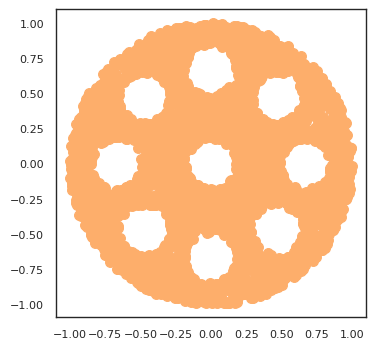

In [6]:
def plot_dataset(train_dataset):
    # Check if the dataset is 2D or 3D
    num_features = train_dataset.features.shape[1]

    # Prepare the figure and axes
    if num_features == 2:
        fig, ax = plt.subplots()
    elif num_features == 3:
        fig = plt.figure()
        ax = fig.add_subplot(111, projection="3d")
    else:
        raise ValueError("Dataset must be either 2D or 3D.")

    # Labels and colors
    labels = [target_class]
    colors = [
        aesthetics.SeabornColors.orange,
        aesthetics.SeabornColors.blue,
    ]

    # Plot each class separately
    for i, label in enumerate(labels):
        if num_features == 2:
            ax.scatter(
                train_dataset.features[train_dataset.labels.squeeze() == label, 0].numpy(),
                train_dataset.features[train_dataset.labels.squeeze() == label, 1].numpy(),
                color=colors[i],
                marker="o",
                s=50,
            )
        elif num_features == 3:
            ax.scatter(
                train_dataset.features[train_dataset.labels.squeeze() == label, 0].numpy(),
                train_dataset.features[train_dataset.labels.squeeze() == label, 1].numpy(),
                train_dataset.features[train_dataset.labels.squeeze() == label, 2].numpy(),
                color=colors[i],
                marker="o",
                s=10,
            )

    # Show the plot
    plt.show()


# Example usage
plot_dataset(train_dataset)


In [7]:
idx = torch.where(train_dataset.labels == target_class)[0]
subset = Subset(train_dataset, idx)
loader = torch.utils.data.DataLoader(subset, batch_size=2_000, shuffle=True)
data, labels = next(iter(loader))

In [8]:
def compute_reference_bases(data):
    # Compute PCA reference basis
    pca = PCA(n_components=3)
    pca_reference_basis = pca.fit_transform(data)

    # Compute Random Projection reference basis
    rp = GaussianRandomProjection(n_components=3, random_state=42)
    rp_reference_basis = rp.fit_transform(data)

    return pca_reference_basis, rp_reference_basis


# Function to align using Procrustes from scipy
def align_using_procrustes(reference_points, new_points):
    _, new_points_aligned, _ = procrustes(reference_points, new_points)
    return new_points_aligned

In [9]:
# Enable Panel for Jupyter
pn.extension()


# Function to update the PCA and LLE plots with persistent axis ranges
def update_plots(new_data, pca_reference_basis, rp_reference_basis):
    # Apply PCA (always using 3 components for now)
    pca = PCA(n_components=3)
    pca_result = pca.fit_transform(new_data)
    aligned_pca_result = align_using_procrustes(pca_reference_basis, pca_result)

    # Initialize PCA figure
    pca_fig = px.scatter_3d(
        x=aligned_pca_result[:, 0], y=aligned_pca_result[:, 1], z=aligned_pca_result[:, 2]
    )
    pca_fig.update_traces(marker=dict(size=1))

    # Check for existing axis range and use it if available
    if "scene" in pca_fig.layout and "xaxis" in pca_fig.layout.scene:
        axis_range = pca_fig.layout.scene.xaxis.range or [-0.05, 0.05]
    else:
        axis_range = [-0.05, 0.05]

    # Update layout with the persistent or default axis range
    pca_fig.update_layout(
        scene=dict(
            xaxis=dict(range=axis_range),
            yaxis=dict(range=axis_range),
            zaxis=dict(range=axis_range),
            aspectmode="cube",  # Ensures equal aspect ratio
            aspectratio=dict(x=1, y=1, z=1),  # Fixed aspect ratio
        )
    )

    # Apply Random Projection (using 3 components)
    rp = GaussianRandomProjection(n_components=3, random_state=42)
    rp_result = rp.fit_transform(new_data)
    aligned_rp_result = align_using_procrustes(rp_reference_basis, rp_result)

    # Initialize RP figure
    rp_fig = px.scatter_3d(
        x=aligned_rp_result[:, 1], y=-aligned_rp_result[:, 2], z=aligned_rp_result[:, 0]
    )
    rp_fig.update_traces(marker=dict(size=2))

    # Check for existing axis range and use it if available
    if "scene" in rp_fig.layout and "xaxis" in rp_fig.layout.scene:
        axis_range = rp_fig.layout.scene.xaxis.range or [-0.05, 0.05]
    else:
        axis_range = [-0.05, 0.05]

    # Update layout with the persistent or default axis range
    rp_fig.update_layout(
        scene=dict(
            xaxis=dict(range=axis_range),
            yaxis=dict(range=axis_range),
            zaxis=dict(range=axis_range),
            aspectmode="cube",  # Ensures equal aspect ratio
            aspectratio=dict(x=1, y=1, z=1),  # Fixed aspect ratio
        )
    )

    return pca_fig, rp_fig


original_scaled_model = ScaledModel.load_model(model, scaled_file_path).eval()
scaled_model = deepcopy(original_scaled_model)
scaled_model.hook_model(True, True, True)
_ = scaled_model.forward_scaled(data)
act_dict = scaled_model.get_activations()
new_keys = range(len(act_dict))
act_dict = OrderedDict(zip(new_keys, act_dict.values()))
pca_reference_basis, rp_reference_basis = compute_reference_bases(act_dict[0])


# Create a slider widget (purely a dummy slider)
slider = pn.widgets.FloatSlider(name="LeakyReLU", start=-2.0, end=2.0, step=0.1, value=0.1)
# Create an IntSlider widget for selecting the layer
layer_select = pn.widgets.IntSlider(
    name="Layer Selector", start=new_keys.start, end=new_keys.stop - 1, step=1, value=0
)


# Interactive function to display the plots
@pn.depends(slider.param.value, layer_select.param.value)
def view(relu_param, layer_index):
    def replace_relu(module, slope, layer_index):
        """
        Recursively replaces ReLU activation with LeakyReLU in a model based on the given index.

        Args:
            module (nn.Module): The model to traverse.
            slope (float): The negative slope for LeakyReLU.
            layer_index (int): The index of the layer to replace.
        """
        current_index = 0  # Counter to track activation layers

        def traverse_and_replace(submodule, counter):
            for name, child in submodule.named_children():
                # If the child is a container (e.g., Sequential), recurse into it
                if isinstance(child, nn.Sequential) or isinstance(child, nn.Module):
                    counter = traverse_and_replace(child, counter)
                # Replace ReLU if the current index matches layer_index
                if isinstance(child, (nn.ReLU, nn.GELU, nn.LeakyReLU)):
                    if counter == layer_index:
                        setattr(submodule, name, nn.LeakyReLU(slope))
                    counter += 1
            return counter

        traverse_and_replace(module, current_index)

    scaled_model = deepcopy(original_scaled_model)
    replace_relu(scaled_model, relu_param, layer_index)
    scaled_model.hook_model(True, True, True)
    _ = scaled_model.forward_scaled(data)
    act_dict = scaled_model.get_activations()
    new_keys = range(len(act_dict))
    act_dict = OrderedDict(zip(new_keys, act_dict.values()))
    pca_fig, rp_fig = update_plots(act_dict[layer_index], pca_reference_basis, rp_reference_basis)
    return pn.Row(pn.pane.Plotly(pca_fig), pn.pane.Plotly(rp_fig), align="center")


# Center everything using Panel's `style` and add the slider with a margin
layout = pn.Column(
    pn.Row(slider, align="center"),
    pn.Row(layer_select, align="center"),
    view,
    align="center",
    sizing_mode="stretch_width",
)

# Serve the layout in the browser
layout.show()

Launching server at http://localhost:36909
